In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
from pathlib import Path
import os
import sklearn
import scipy
import numpy as np
import sceleto2 as scl
import pickle
import glob
import os
import scrublet as scr
import matplotlib.pyplot as plt


sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, dpi_save=300, figsize=(5,5))
sc.settings.figdir = "./figures"
sc.settings.autosave = False
random_seed = 0

from datetime import date
TODAY = date.today()
print(TODAY)

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-13


## PB utils

In [28]:
def pc_loadings_both_sides(adata, pc=1, n=20):
    s = pd.Series(
        adata.varm["PCs"][:, pc - 1],
        index=adata.var_names
    ).sort_values()

    negative = s.head(n).to_frame("loading")
    positive = s.tail(n).sort_values(ascending=False).to_frame("loading")

    return positive, negative

def print_pc_genes(adata, pcs=(1, 2), n=30):
    for pc in pcs:
        s = pd.Series(
            adata.varm["PCs"][:, pc - 1],
            index=adata.var_names
        )

        print(f"\n===== PC{pc} POSITIVE =====")
        print(", ".join(s.nlargest(n).index))

        print(f"\n===== PC{pc} NEGATIVE =====")
        print(", ".join(s.nsmallest(n).index))


print_pc_genes(pb_pca, pcs=(1, 2), n=50)


===== PC1 POSITIVE =====
PCDH15, PLCG2, CCK, NAIP, MCF2L2, FAM177B, TSPYL1, MICAL3, ARL17B, STXBP1, SERPINI1, CPE, GNG2, OLFM1, VPS45, CTSC, IVNS1ABP, S100Z, MB21D2, SPOPL, IL1B, HS6ST3, FAM3C, FRMD5, CCL2, ENC1, HLA-DRA, ENOX1, HLA-E, PRDM11, IRAK2, CNTN5, MSR1, TSC22D1, VSNL1, FRY, DOCK3, DENND3, LPAR6, IRF8, NCALD, PLCL1, RPL32, TGFBR1, GLCE, CECR2, ZFYVE28, UHMK1, MRC2, ATP11A

===== PC1 NEGATIVE =====
SERPINE1, ZBTB16, PGLYRP2, SOX18, FIGLA, TNFRSF4, FKBP5, SIGLEC8, KCNA5, PGF, RAB34, SFTPC, PLA2G4E, SCN4A, LYPD3, TBC1D3L, GGT5, TRAPPC5, ASB4, ALOX15B, CARNS1, IFITM3, PLGLB2, VSIG10L, UPB1, IDUA, DMRTA2, KMO, TMEM114, DLX4, LOXL1, RGPD4, INSR, CHRNA2, ADH4, ROS1, BPIFC, DNLZ, CLEC18B, SLC39A4, SYT15, CRIP3, CRYBB2, TP63, ZBP1, ATP2B4, TMEM165, RRM2, SLC5A12, WNT8A

===== PC2 POSITIVE =====
PCDH9, KCNIP4, LSAMP, NRG3, SNTG1, CSMD1, ERBB4, KALRN, ANKS1B, ADGRB3, MAGI2, CNTNAP2, CDC42BPA, RALYL, TRIM9, LRRC7, SH3GL3, NRXN1, NLGN1, NEGR1, CSMD3, ANK3, CNTNAP5, MDGA2, CLMN, CADPS, NCA

# 1. Check clinical metadata

In [2]:
adata = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/integrated/snRNAseq_microglia_cnmfr3_k9.h5ad")
adata

AnnData object with n_obs × n_vars = 30026 × 14642
    obs: 'brain_region', 'platform', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_scores', 'predicted_doublets', 'celltype_lv1', 'study', 'gsm', 'tissue_id', 'donor_id_global', 'brain_region_source', 'tissue_compartment', 'lesion_relation', 'hemisphere', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'scVI_leiden05', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP3_bin', 'GEP3_decile', 'myeloid_identity'
    var: 'mt', '

In [3]:
print(adata.obs['sample_id'].value_counts())

sample_id
P82_Donor5           2727
G120_D.3             2536
A76_Donor4           2351
Patient-3_snRNA      2250
P76_Donor4           1957
Patient-2_snRNA      1720
Patient-4_snRNA      1589
Control-3_snRNA      1548
A56_Donor1           1388
Patient-1_snRNA      1261
A82_Donor5           1022
G133_D.2             1013
Control-1_snRNA       900
G133_N.2              894
Control-2_snRNA       877
RM95_snRNA_rep2       858
B01_total_nuclei      797
RM77_snRNA_rep2       745
RM95_snRNA_rep1       595
RM102_snRNA_rep1      492
RM77_snRNA_rep1       482
RM101_snRNA_rep2      443
RM102_snRNA_rep2      386
G120_D.2              341
P57_Donor2            249
HC14_total_nuclei     227
A57_Donor2            192
G129_D                 87
G159_D                 31
HC35_total_nuclei      17
A67_Donor3             15
G210_D                 10
P67_Donor3              9
G187_D                  5
G171_D                  5
P56_Donor1              3
G150_D                  2
G120_N.1                2
Na

In [4]:
print(adata.obs['diagnosis_raw'].value_counts())
print(adata.obs['diagnosis_harmonized'].value_counts())

diagnosis_raw
cryptogenic temporal lobe epilepsy                                                   9913
FCD IIIa with hippocampal sclerosis                                                  6820
FCD_typeIIb                                                                          4018
temporal lobe epilepsy                                                               4001
isolated hippocampal sclerosis (iHS); relatively non-epileptic temporal neocortex    3325
Normal                                                                                896
epilepsy; normal-appearing lateral temporal cortex                                    797
postmortem healthy control                                                            244
FCD_typeIIa                                                                            12
Name: count, dtype: int64
diagnosis_harmonized
nonlesional epilepsy    14711
FCD                     11746
HS                       3325
HC                        244
Name: cou

In [5]:
(
    adata.obs
    .groupby(["diagnosis_harmonized", "study"], observed=True)
    .agg(
        n_cells=("sample_id", "size"),
        n_samples=("sample_id", "nunique"),
        n_donors=("donor_id_global", "nunique"),
    )
)

n_cells  n_samples  n_donors
diagnosis_harmonized study                                   
FCD                  galvao         4926         11         8
                     liu            6820          4         4
HC                   pappalardo      244          2         2
HS                   liu            3325          3         3
nonlesional epilepsy ayhan          9913         10         5
                     pappalardo      797          1         1
                     thrupp         4001          7         4

# 2. Aggregate, generate pseudobulk

In [10]:
adata

AnnData object with n_obs × n_vars = 41237 × 14642
    obs: 'brain_region', 'platform', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_scores', 'predicted_doublets', 'celltype_lv1', 'study', 'gsm', 'tissue_id', 'donor_id_global', 'brain_region_source', 'tissue_compartment', 'lesion_relation', 'hemisphere', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'scVI_leiden05', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8'
    var: 'mt', 'ribo', 'hb'
    obsm: 'X_umap_scVI'
    layers: 'counts

In [6]:
from scipy import sparse


# ============================================================
# 0. Settings
# ============================================================

COUNT_LAYER = "counts"

meta_cols = [
    "study",
    "sample_id",
    "donor_id",
    "diagnosis_raw",
    "diagnosis_harmonized",
    "fcd_class",
    "mtoropathy_status",
    "tissue_state",
    "hemisphere",
    "age",
    "sex",
    "epilepsy_duration",
]

# only keep columns that actually exist
meta_cols = [c for c in meta_cols if c in adata.obs.columns]


# ============================================================
# 1. Check raw count matrix
# ============================================================

if COUNT_LAYER not in adata.layers:
    raise ValueError(f"`adata.layers['{COUNT_LAYER}']` does not exist.")

counts = adata.layers[COUNT_LAYER]

if not sparse.issparse(counts):
    counts = sparse.csr_matrix(counts)
else:
    counts = counts.tocsr()

if counts.data.min() < 0:
    raise ValueError("Count matrix contains negative values.")

# optional sanity check: raw counts should be integer-like
if not np.allclose(counts.data[:100000], np.round(counts.data[:100000])):
    print("WARNING: counts layer does not appear to contain integer raw counts.")


# ============================================================
# 2. Make globally unique pseudobulk ID
# ============================================================

adata.obs["pb_id"] = (
    adata.obs["study"].astype(str)
    + "::"
    + adata.obs["sample_id"].astype(str)
)

pb_ids = pd.Index(adata.obs["pb_id"].unique(), name="pb_id")

print(f"{adata.n_obs:,} cells")
print(f"{len(pb_ids):,} pseudobulk samples")


# ============================================================
# 3. Check that sample-level metadata are consistent
# ============================================================

for col in meta_cols:
    n_unique = (
        adata.obs.groupby("pb_id", observed=True)[col]
        .nunique(dropna=True)
    )

    bad = n_unique[n_unique > 1]

    if len(bad) > 0:
        print(f"\nWARNING: `{col}` has multiple values within these samples:")
        print(bad)


# ============================================================
# 4. Cell -> sample aggregation matrix
# ============================================================

pb_cat = pd.Categorical(
    adata.obs["pb_id"],
    categories=pb_ids,
)

row = pb_cat.codes
col = np.arange(adata.n_obs)

# matrix shape:
# n_samples × n_cells
sample_indicator = sparse.csr_matrix(
    (
        np.ones(adata.n_obs, dtype=np.int64),
        (row, col),
    ),
    shape=(len(pb_ids), adata.n_obs),
)

# sum raw counts over cells
# shape:
# n_samples × n_genes
pb_counts = sample_indicator @ counts
pb_counts = pb_counts.tocsr()


# ============================================================
# 5. Build sample metadata
# ============================================================

def first_non_null(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan


pb_obs = (
    adata.obs
    .groupby("pb_id", observed=True)[meta_cols]
    .agg(first_non_null)
    .reindex(pb_ids)
)

# number of microglia/nuclei contributing to each PB
pb_obs["n_cells"] = (
    adata.obs["pb_id"]
    .value_counts()
    .reindex(pb_ids)
    .astype(int)
)

# library size after aggregation
pb_obs["total_counts"] = np.asarray(pb_counts.sum(axis=1)).ravel()


# ============================================================
# 6. Construct pseudobulk AnnData
# ============================================================

pb = ad.AnnData(
    X=pb_counts.copy(),
    obs=pb_obs.copy(),
    var=adata.var.copy(),
)

# explicitly preserve raw counts
pb.layers["counts"] = pb_counts.copy()

pb.obs_names = pb_ids.astype(str)

print(pb)

30,026 cells
38 pseudobulk samples
AnnData object with n_obs × n_vars = 38 × 14642
    obs: 'study', 'sample_id', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'tissue_state', 'hemisphere', 'sex', 'n_cells', 'total_counts'
    var: 'mt', 'ribo', 'hb', 'mean', 'std'
    layers: 'counts'


# 3. QC

In [7]:
pb.obs[
    [
        c for c in [
            "study",
            "sample_id",
            "donor_id",
            "diagnosis_harmonized",
            "diagnosis_raw",
            "n_cells",
            "total_counts",
        ]
        if c in pb.obs.columns
    ]
].sort_values(["study", "sample_id"])

,study,sample_id,diagnosis_harmonized,diagnosis_raw,n_cells,total_counts
pb_id,,,,,,
ayhan::A56_Donor1,ayhan,A56_Donor1,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,1388,870879.0
ayhan::A57_Donor2,ayhan,A57_Donor2,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,192,122933.0
ayhan::A67_Donor3,ayhan,A67_Donor3,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,15,7849.0
ayhan::A76_Donor4,ayhan,A76_Donor4,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,2351,3173588.0
ayhan::A82_Donor5,ayhan,A82_Donor5,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,1022,1511151.0
ayhan::P56_Donor1,ayhan,P56_Donor1,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,3,1629.0
ayhan::P57_Donor2,ayhan,P57_Donor2,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,249,168492.0
ayhan::P67_Donor3,ayhan,P67_Donor3,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,9,2151.0
ayhan::P76_Donor4,ayhan,P76_Donor4,nonlesional epilepsy,cryptogenic temporal lobe epilepsy,1957,2381796.0


In [8]:
pb.obs["n_cells"].describe()

count      38.000000
mean      790.157895
std       801.745141
min         2.000000
25%        45.000000
50%       543.500000
75%      1201.250000
max      2727.000000
Name: n_cells, dtype: float64

In [9]:
pb.obs.sort_values("n_cells")[
    [
        "study",
        "sample_id",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
    ]
]

,study,sample_id,diagnosis_harmonized,n_cells,total_counts
pb_id,,,,,
galvao::G120_N.1,galvao,G120_N.1,FCD,2,2425.0
galvao::G150_D,galvao,G150_D,FCD,2,924.0
ayhan::P56_Donor1,ayhan,P56_Donor1,nonlesional epilepsy,3,1629.0
galvao::G171_D,galvao,G171_D,FCD,5,4990.0
galvao::G187_D,galvao,G187_D,FCD,5,3143.0
ayhan::P67_Donor3,ayhan,P67_Donor3,nonlesional epilepsy,9,2151.0
galvao::G210_D,galvao,G210_D,FCD,10,9630.0
ayhan::A67_Donor3,ayhan,A67_Donor3,nonlesional epilepsy,15,7849.0
pappalardo::HC35_total_nuclei,pappalardo,HC35_total_nuclei,HC,17,16246.0


# 4. PCA

## Without QC

In [10]:
pb_pca = pb.copy()

# library-size normalization
sc.pp.normalize_total(pb_pca, target_sum=1e6)

# log-CPM
sc.pp.log1p(pb_pca)

# HVG
sc.pp.highly_variable_genes(
    pb_pca,
    n_top_genes=3000,
    flavor="seurat"
)

# PCA
sc.pp.pca(
    pb_pca,
    n_comps=20,
    mask_var="highly_variable"
)

normalizing counts per cell


    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=20
    finished (0:00:00)


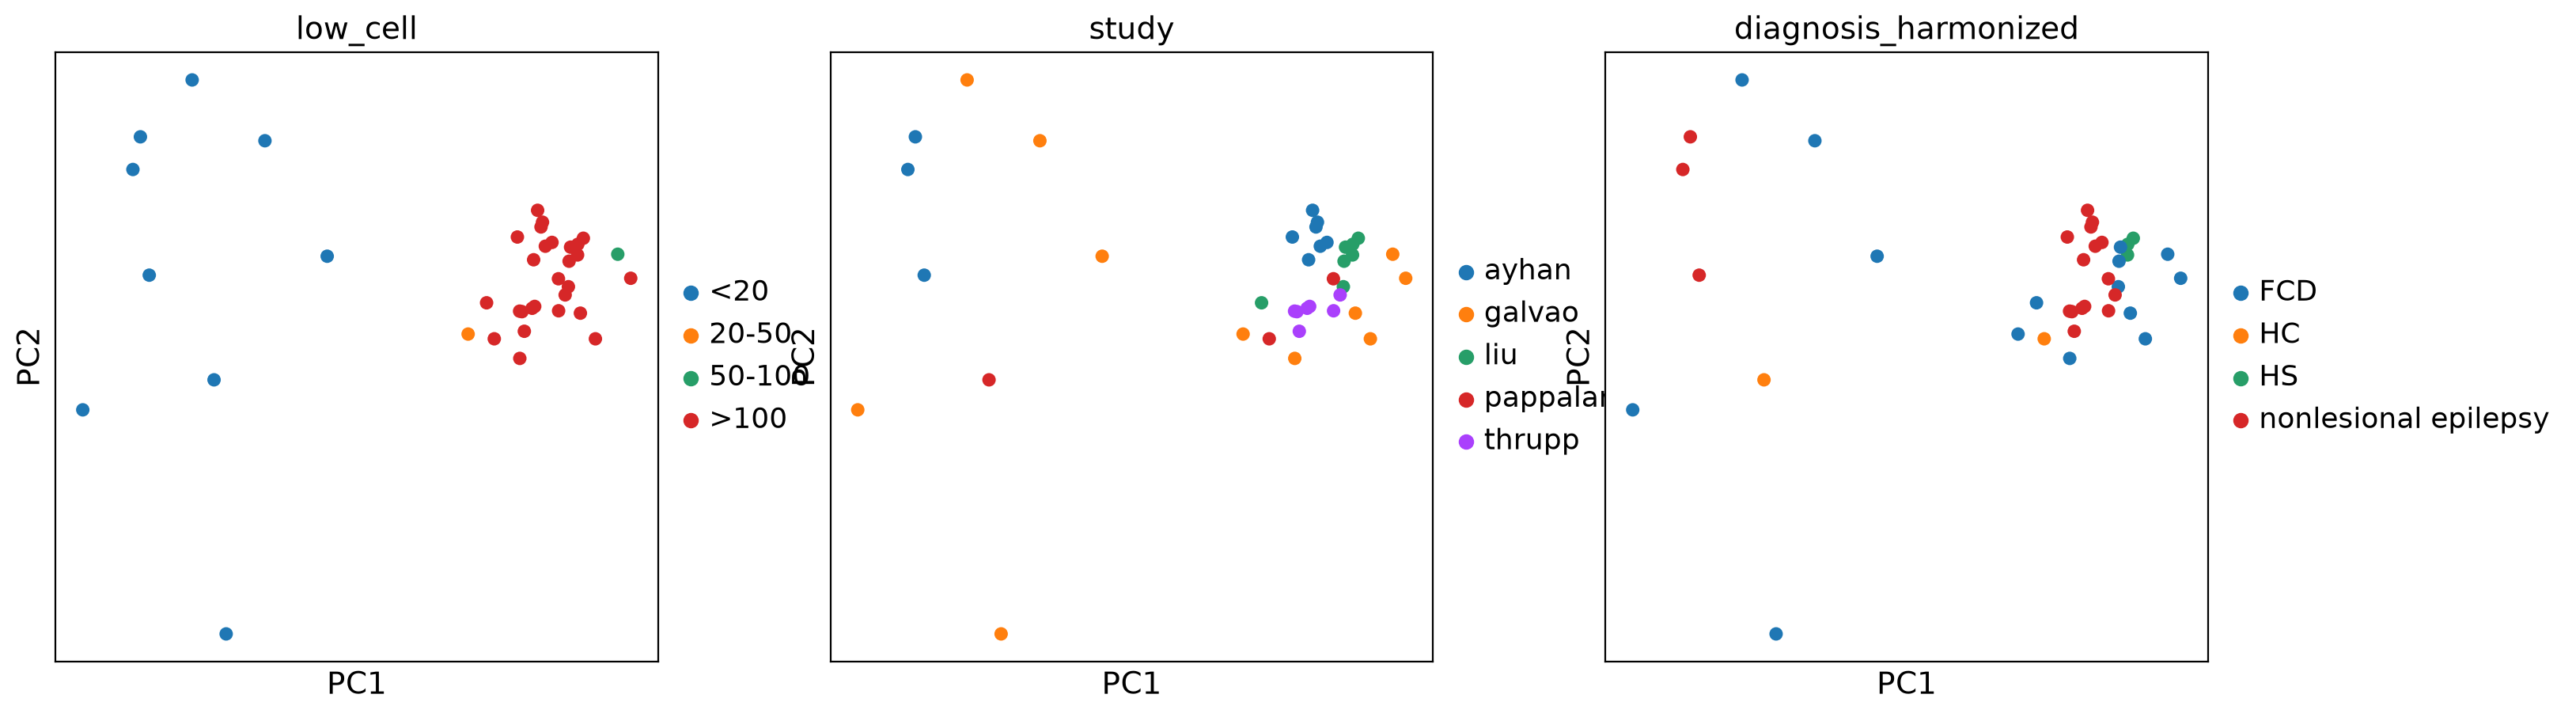

In [11]:
pb_pca.obs["low_cell"] = pd.cut(
    pb_pca.obs["n_cells"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["<20", "20-50", "50-100", ">100"]
)

sc.pl.pca(
    pb_pca,
    color=["low_cell", "study", "diagnosis_harmonized"],
    size=150,
)

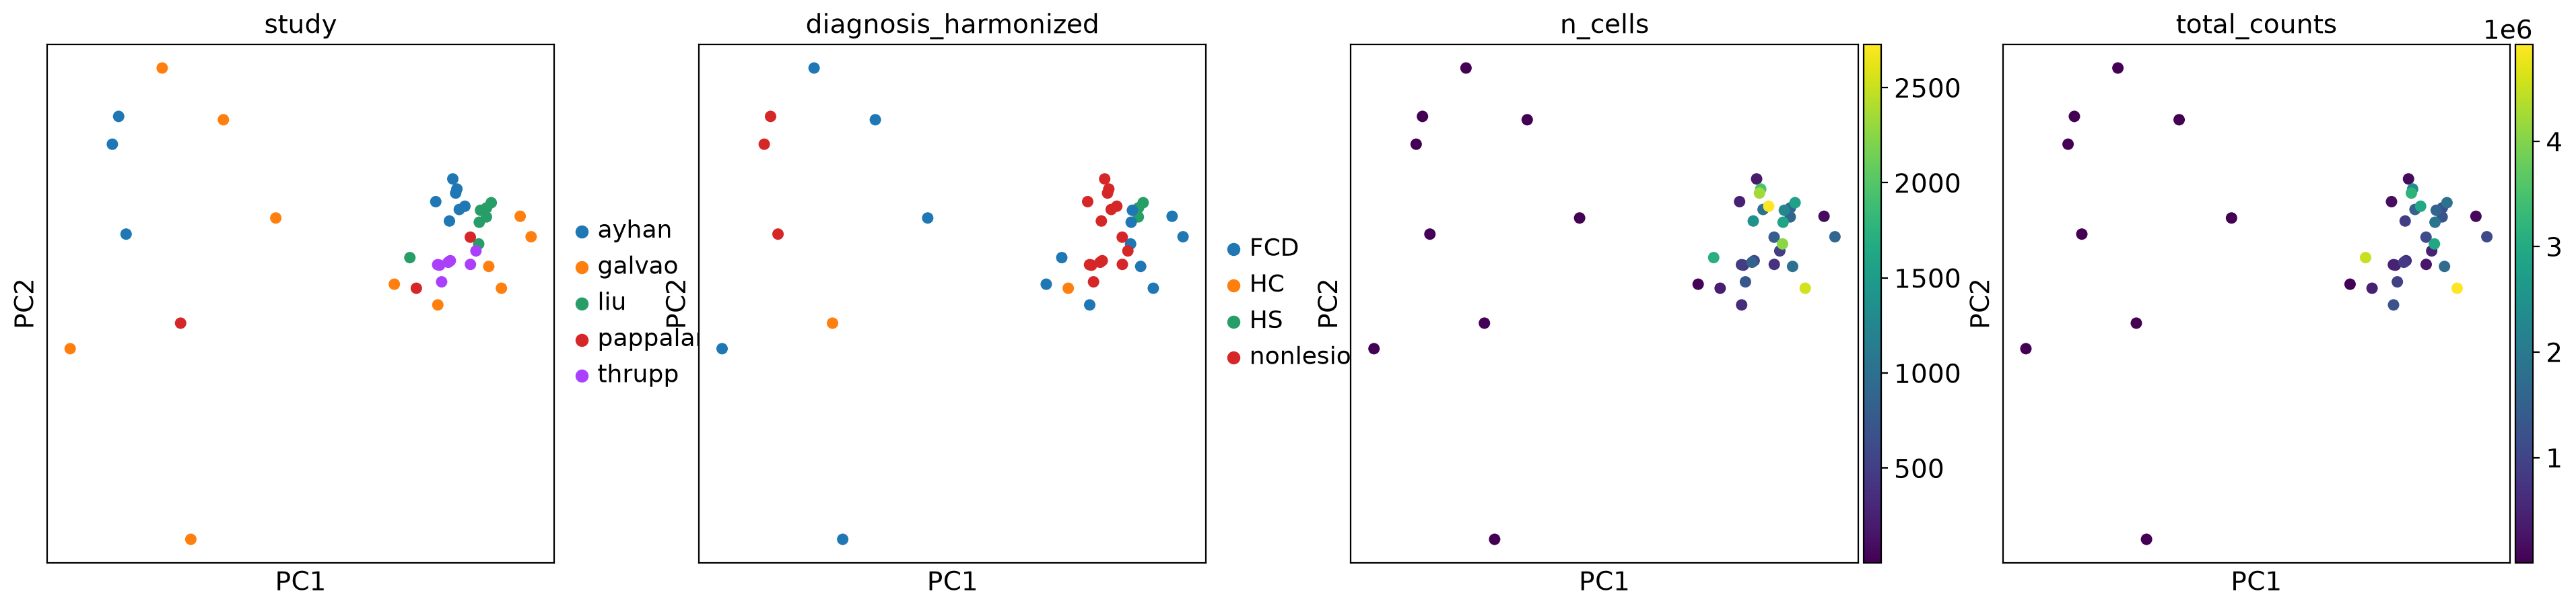

In [12]:
sc.pl.pca(
    pb_pca,
    color=[
        "study",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
    ],
    size=150,
)

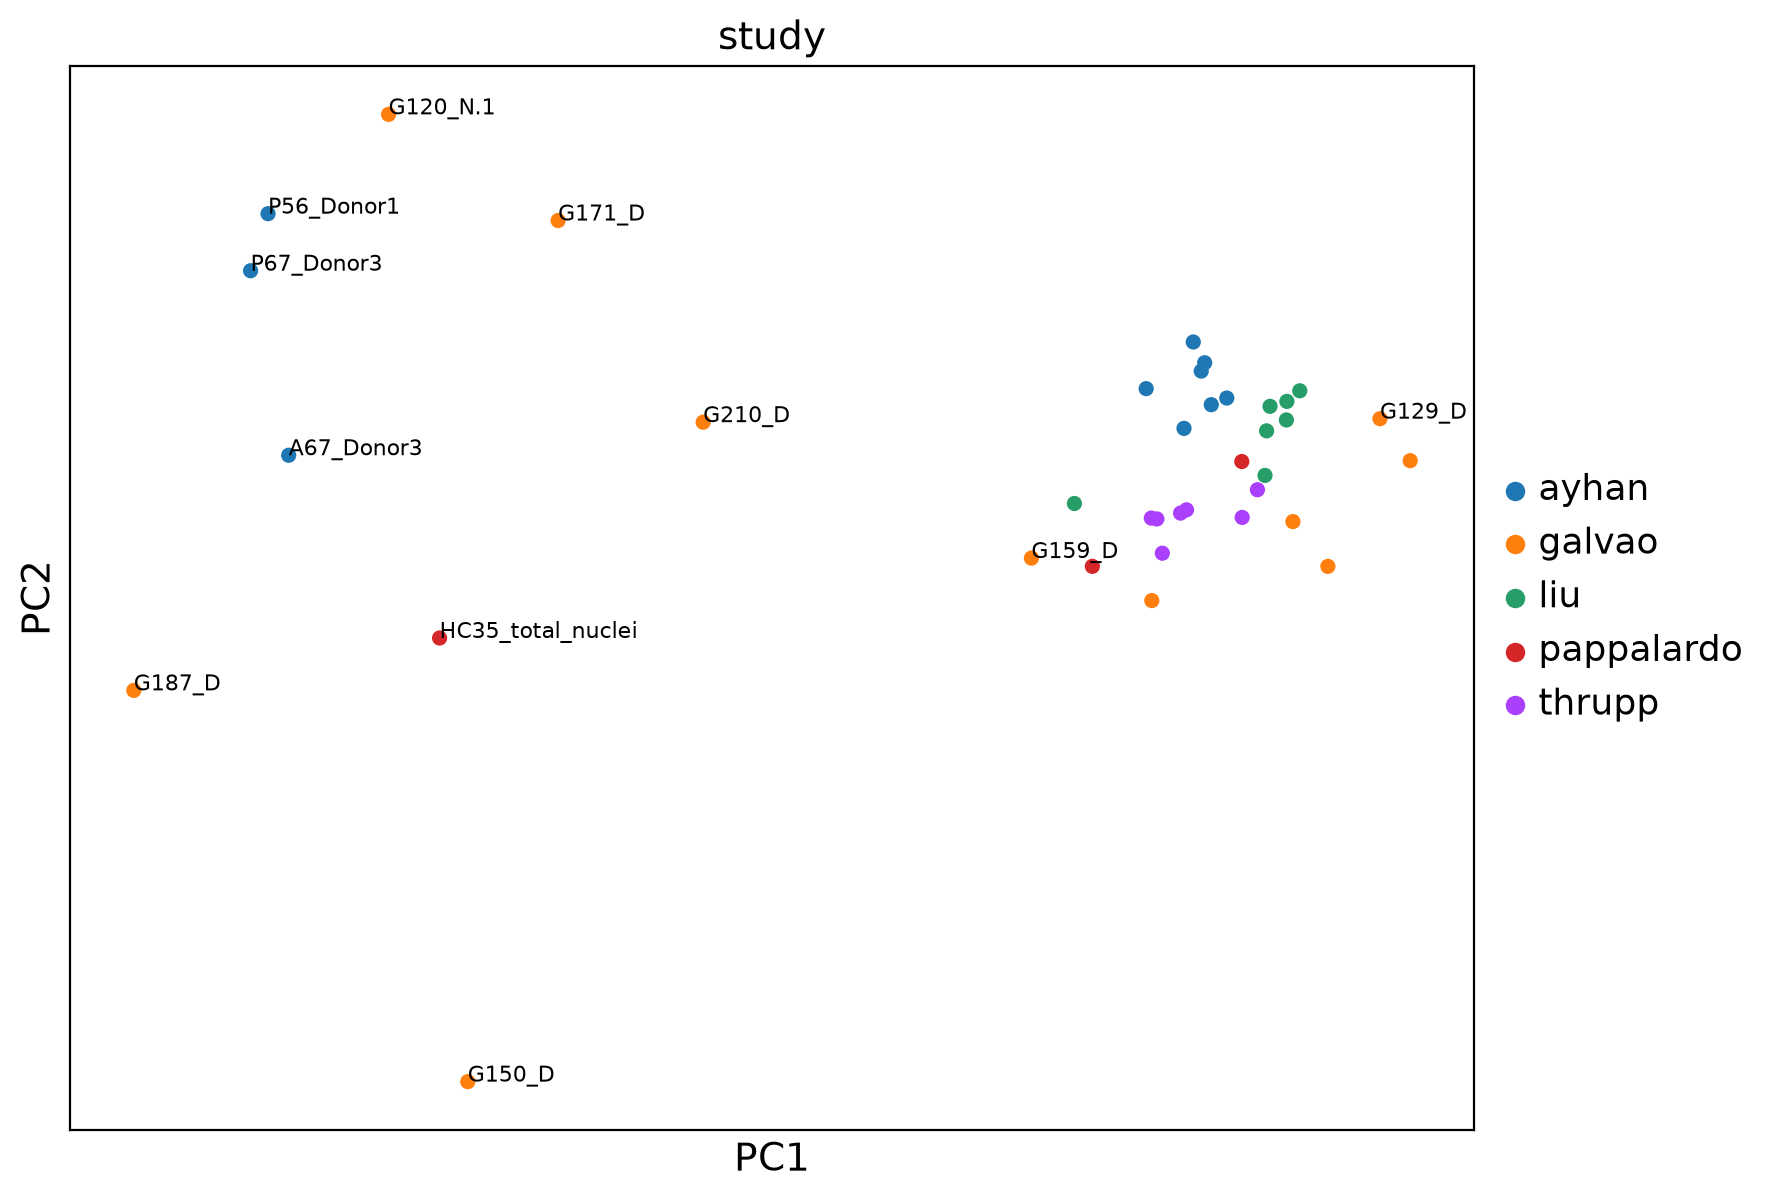

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

sc.pl.pca(
    pb_pca,
    color="study",
    size=120,
    ax=ax,
    show=False,
)

for i in range(pb_pca.n_obs):
    if pb_pca.obs.iloc[i]["n_cells"] < 100:
        ax.annotate(
            pb_pca.obs.iloc[i]["sample_id"],
            pb_pca.obsm["X_pca"][i, :2],
            fontsize=8,
        )

plt.show()

In [ ]:
pc1_pos, pc1_neg = pc_loadings_both_sides(pb_pca, pc=1, n=30)

display(pc1_pos)
display(pc1_neg)

In [ ]:
pc2_pos, pc2_neg = pc_loadings_both_sides(pb_pca, pc=2, n=30)

display(pc2_pos)
display(pc2_neg)

## Low quality cell measure

In [14]:
import numpy as np
import pandas as pd

# distance from global PCA centroid using first 5 PCs
X = pb_pca.obsm["X_pca"][:, :5]

center = X.mean(axis=0)

pb_pca.obs["pca_distance"] = np.sqrt(
    ((X - center) ** 2).sum(axis=1)
)

pb_pca.obs[
    [
        "study",
        "sample_id",
        "n_cells",
        "total_counts",
        "pca_distance",
    ]
].sort_values("pca_distance", ascending=False)

,study,sample_id,n_cells,total_counts,pca_distance
pb_id,,,,,
galvao::G120_N.1,galvao,G120_N.1,2,2425.0,134.435898
ayhan::P67_Donor3,ayhan,P67_Donor3,9,2151.0,128.545761
galvao::G150_D,galvao,G150_D,2,924.0,127.308571
ayhan::P56_Donor1,ayhan,P56_Donor1,3,1629.0,126.831421
galvao::G171_D,galvao,G171_D,5,4990.0,123.024696
galvao::G187_D,galvao,G187_D,5,3143.0,109.298164
ayhan::A67_Donor3,ayhan,A67_Donor3,15,7849.0,74.657806
pappalardo::HC35_total_nuclei,pappalardo,HC35_total_nuclei,17,16246.0,67.987015
galvao::G210_D,galvao,G210_D,10,9630.0,54.652481


In [15]:
X = pb_pca.obsm["X_pca"][:, :5]

dist = np.zeros(pb_pca.n_obs)

for study in pb_pca.obs["study"].unique():
    mask = pb_pca.obs["study"].values == study

    center = X[mask].mean(axis=0)

    dist[mask] = np.sqrt(
        ((X[mask] - center) ** 2).sum(axis=1)
    )

pb_pca.obs["within_study_pca_distance"] = dist

pb_pca.obs[
    [
        "study",
        "sample_id",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
        "within_study_pca_distance",
    ]
].sort_values(
    "within_study_pca_distance",
    ascending=False
)

,study,sample_id,diagnosis_harmonized,n_cells,total_counts,within_study_pca_distance
pb_id,,,,,,
galvao::G120_N.1,galvao,G120_N.1,FCD,2,2425.0,123.297546
galvao::G150_D,galvao,G150_D,FCD,2,924.0,111.223602
ayhan::P56_Donor1,ayhan,P56_Donor1,nonlesional epilepsy,3,1629.0,110.718430
ayhan::P67_Donor3,ayhan,P67_Donor3,nonlesional epilepsy,9,2151.0,110.288956
galvao::G171_D,galvao,G171_D,FCD,5,4990.0,109.801834
galvao::G187_D,galvao,G187_D,FCD,5,3143.0,100.919090
ayhan::A67_Donor3,ayhan,A67_Donor3,nonlesional epilepsy,15,7849.0,63.710106
galvao::G133_N.2,galvao,G133_N.2,FCD,894,1110827.0,52.371811
galvao::G129_D,galvao,G129_D,FCD,87,97314.0,50.984699


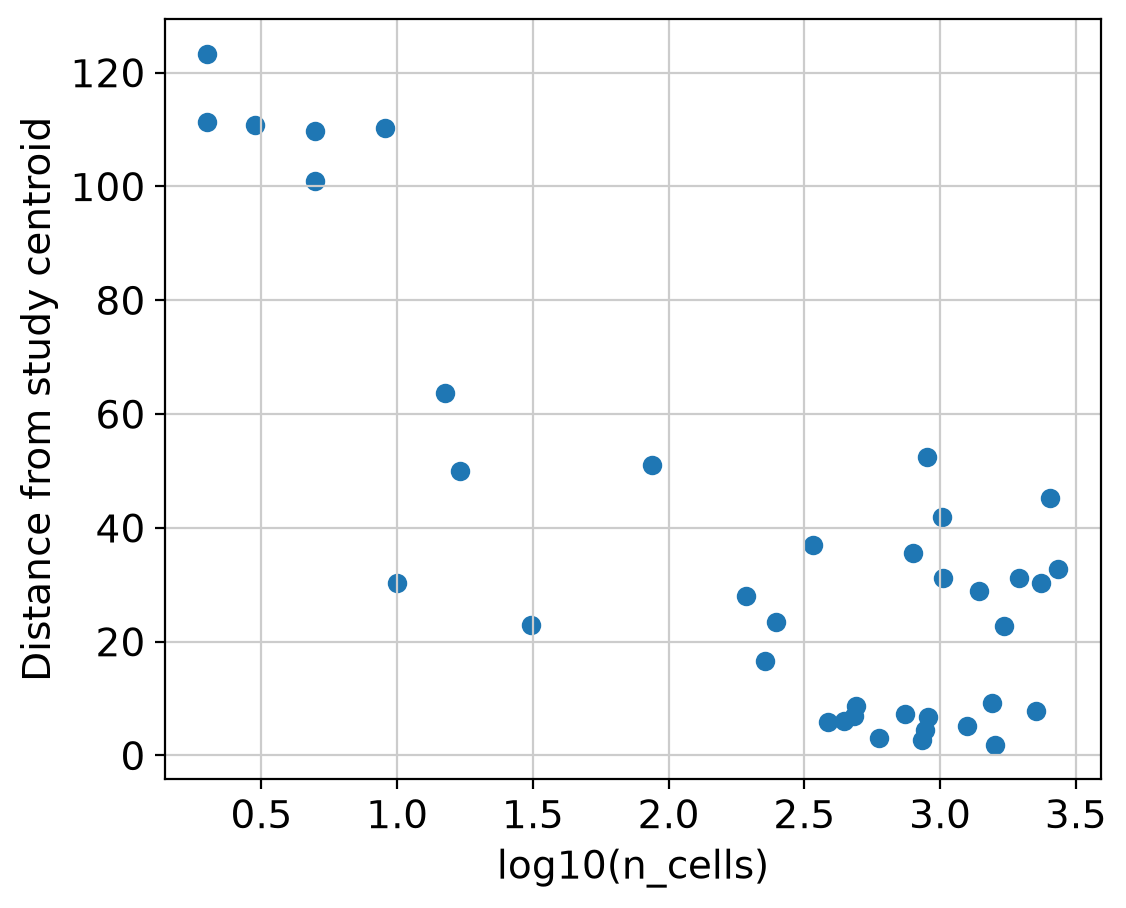

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(
    np.log10(pb_pca.obs["n_cells"]),
    pb_pca.obs["within_study_pca_distance"],
)

plt.xlabel("log10(n_cells)")
plt.ylabel("Distance from study centroid")

plt.show()

## With cell/gene qc (min counts = 10 in min 3 samples, min cells > 20)

In [19]:
pb_cf = pb[pb.obs["n_cells"] >= 20].copy()

In [21]:
pb_cf

AnnData object with n_obs × n_vars = 29 × 14642
    obs: 'study', 'sample_id', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'tissue_state', 'hemisphere', 'sex', 'n_cells', 'total_counts'
    var: 'mt', 'ribo', 'hb', 'mean', 'std'
    layers: 'counts'

In [22]:
X = pb_cf.layers["counts"]

# expressed at >= 10 counts in at least 3 PB samples
keep = (
    np.asarray((X >= 10).sum(axis=0)).ravel()
    >= 3
)

pb_f = pb_cf[:, keep].copy()

print(pb_cf.n_vars, "->", pb_f.n_vars)

14642 -> 11847


In [23]:
pb_f.X.max()

np.float64(43931.0)

In [24]:
# library-size normalization
sc.pp.normalize_total(pb_f, target_sum=1e6)

# log-CPM
sc.pp.log1p(pb_f)

# HVG
sc.pp.highly_variable_genes(
    pb_f,
    n_top_genes=3000,
    flavor="seurat"
)

# PCA
sc.pp.pca(
    pb_f,
    n_comps=20,
    mask_var="highly_variable"
)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=20
    finished (0:00:00)


In [25]:
pb_f.write("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/pseudobulk/snRNAseq_microglia_cnmfr3_k9_pb_cellgenefiltered.h5ad")

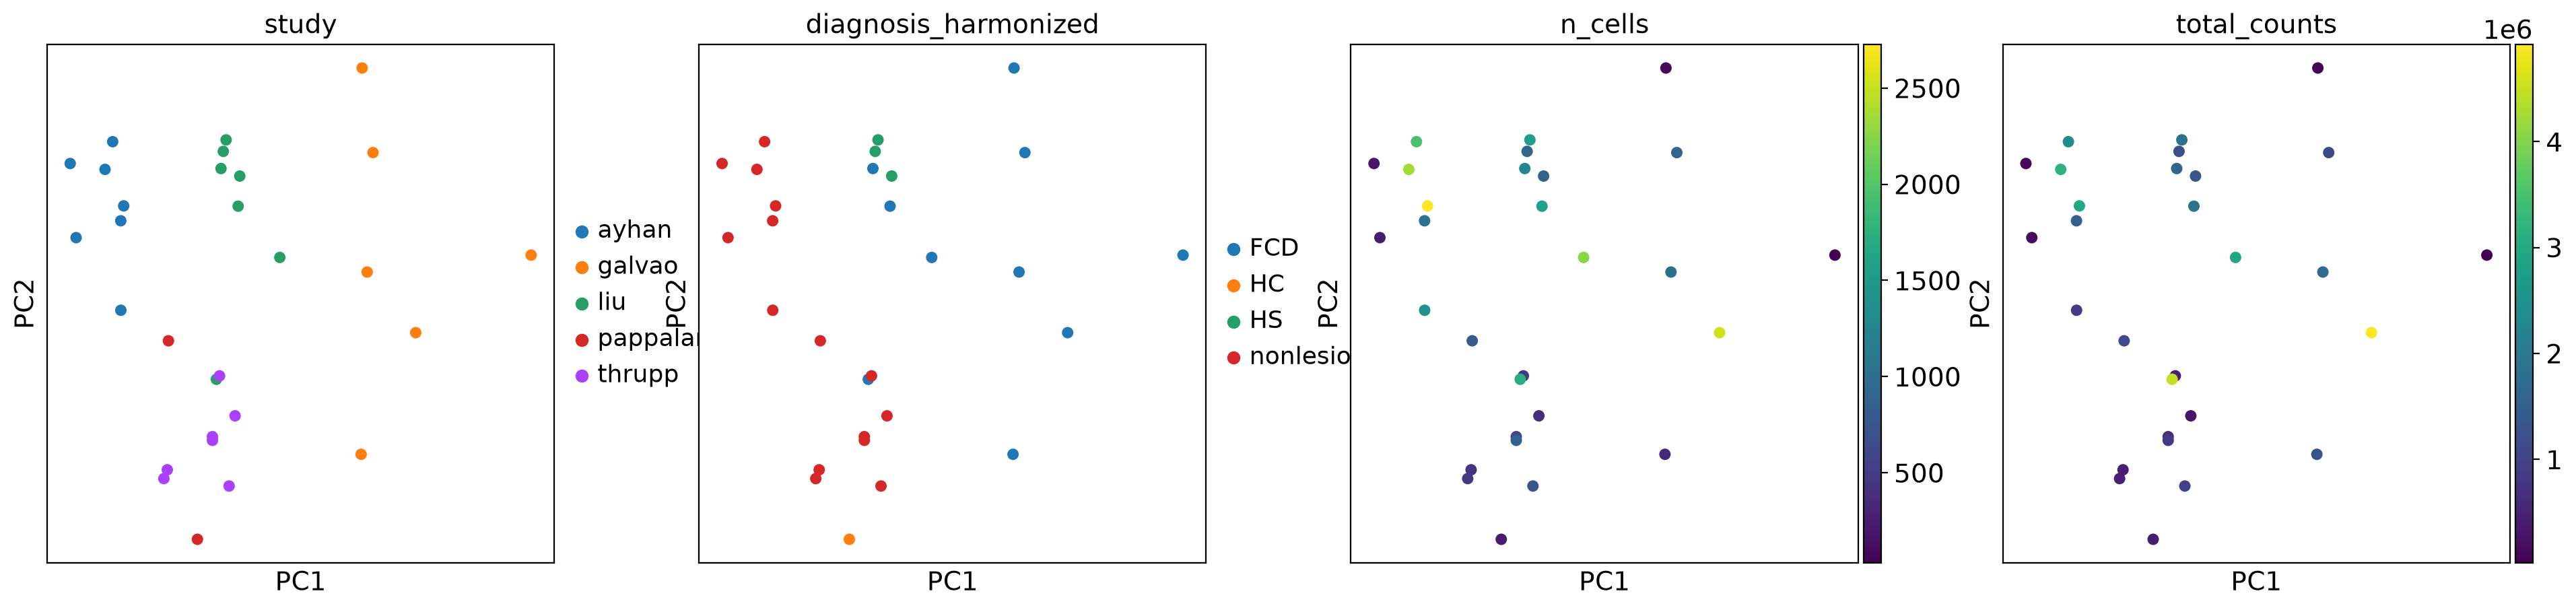

In [26]:
sc.pl.pca(
    pb_f,
    color=[
        "study",
        "diagnosis_harmonized",
        "n_cells",
        "total_counts",
    ],
    size=150,
)

In [29]:
print_pc_genes(pb_f, pcs=(1, 2), n=50)


===== PC1 POSITIVE =====
CALM2, MIF, PTGDS, NDUFA13, ARL6IP1, COX8A, COX6A1, FXYD6, NDUFA11, ARF3, PPP2CA, MTAP, RNASEK, NEDD8, RPL18A, FIP1L1, UQCR11, ATP1A3, RNASET2, TMEM14B, FKBP1A, TIA1, ZNF37A, CHURC1, STX16, SPECC1L, BLOC1S6, ACSL6, SLC35A3, TUBB3, HSPE1, ZMYM6, PARL, ERCC5, NPDC1, DEPDC5, RAD50, CYP51A1, CKLF, TARDBP, CD59, COMMD7, RPS18, ATF7, CHMP4A, KRTCAP2, ACAD11, TRAPPC5, TBCEL, GNG10

===== PC1 NEGATIVE =====
SERPINE1, FKBP5, ZBTB16, PDK4, RNASE10, TIMM23B, PER1, NR4A3, JDP2, GRAPL, CPA6, KCNAB1, DDIT4, BAIAP2L1, OOEP, DOCK5, SAMD3, IFNLR1, LRP4, CPM, PLEKHA7, FAM177B, RGS1, CCND3, CFTR, PRRG4, SLC14A1, TEX14, NR4A1, RYR3, COL24A1, HFM1, CERCAM, SAMD5, CSGALNACT1, GGACT, DPYD, INPP4B, CHRFAM7A, MRC1, ITGA8, BAIAP2L2, ZFPM2, HYDIN, SPDYE16, ALOX15B, PKP2, NHSL1, SLC47A1, MECOM

===== PC2 POSITIVE =====
ZNF506, EPHA7, KCNJ3, COL5A2, ST6GALNAC5, PCDH15, PPM1E, EPHA4, CPEB1, KCND2, LRFN5, GRIK2, NXPH1, DCC, TRPC4, NRG3, SNTG1, NLGN1, ACSL6, LSAMP, STXBP5L, CCSER1, FXYD6, AN

## cNMF GEP correlation

In [30]:
adata

AnnData object with n_obs × n_vars = 30026 × 14642
    obs: 'brain_region', 'platform', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_scores', 'predicted_doublets', 'celltype_lv1', 'study', 'gsm', 'tissue_id', 'donor_id_global', 'brain_region_source', 'tissue_compartment', 'lesion_relation', 'hemisphere', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'scVI_leiden05', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP3_bin', 'GEP3_decile', 'myeloid_identity', 'pb_id'
    var

In [31]:
gep_cols = [f"GEP{i}" for i in range(1, 10)]

gep_by_sample = (
    adata.obs
    .groupby("sample_id")[gep_cols]
    .mean()
)

pb_f.obs[gep_cols] = gep_by_sample.reindex(
    pb_f.obs["sample_id"]
).to_numpy()

/tmp/ipykernel_3639105/1888526120.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample_id")[gep_cols]


In [32]:
pb_f.obs

,study,sample_id,diagnosis_raw,diagnosis_harmonized,fcd_class,mtoropathy_status,tissue_state,hemisphere,sex,n_cells,total_counts,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8,GEP9
pb_id,,,,,,,,,,,,,,,,,,,,
ayhan::A56_Donor1,ayhan,A56_Donor1,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,1388,870879.0,0.255013,0.409511,0.020214,0.063735,0.093355,0.007734,0.143126,0.004796,0.002515
ayhan::A76_Donor4,ayhan,A76_Donor4,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,M,2351,3173588.0,0.061552,0.470712,0.244694,0.015225,0.096272,0.011283,0.093266,0.004591,0.002405
ayhan::P82_Donor5,ayhan,P82_Donor5,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,2727,2953956.0,0.145980,0.539725,0.145530,0.025161,0.035105,0.036540,0.058597,0.010208,0.003154
ayhan::A82_Donor5,ayhan,A82_Donor5,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,1022,1511151.0,0.129189,0.545883,0.107763,0.026110,0.064470,0.029497,0.081720,0.012262,0.003104
ayhan::P76_Donor4,ayhan,P76_Donor4,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,M,1957,2381796.0,0.028995,0.533641,0.291919,0.008911,0.055416,0.029947,0.044854,0.003932,0.002384
ayhan::A57_Donor2,ayhan,A57_Donor2,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,192,122933.0,0.068851,0.315045,0.314143,0.035330,0.030754,0.012689,0.213540,0.006205,0.003442
ayhan::P57_Donor2,ayhan,P57_Donor2,cryptogenic temporal lobe epilepsy,nonlesional epilepsy,NA,no,frozen,unknown,F,249,168492.0,0.161626,0.448728,0.198025,0.029825,0.071906,0.012481,0.063596,0.010287,0.003525
galvao::G120_D.3,galvao,G120_D.3,FCD_typeIIb,FCD,II,yes,frozen,unknown,F,2536,4916535.0,0.149746,0.009385,0.020732,0.502804,0.033934,0.238792,0.016779,0.006241,0.021585
galvao::G120_D.2,galvao,G120_D.2,FCD_typeIIb,FCD,II,yes,frozen,unknown,F,341,1238321.0,0.263442,0.029918,0.009018,0.533505,0.105559,0.032403,0.007596,0.002598,0.015960


In [33]:
import scipy.stats as stats

for pc in [0, 1]:
    r, p = stats.spearmanr(
        pb_f.obsm["X_pca"][:, pc],
        pb_f.obs["GEP1"]
    )
    print(f"PC{pc+1}: rho={r:.3f}, p={p:.3g}")

PC1: rho=0.232, p=0.226
PC2: rho=-0.668, p=7.39e-05


In [34]:
import scipy.stats as stats

for pc in [0, 1]:
    r, p = stats.spearmanr(
        pb_f.obsm["X_pca"][:, pc],
        pb_f.obs["GEP2"]
    )
    print(f"PC{pc+1}: rho={r:.3f}, p={p:.3g}")

PC1: rho=-0.835, p=1.71e-08
PC2: rho=-0.111, p=0.567


In [35]:
import scipy.stats as stats

for pc in [0, 1]:
    r, p = stats.spearmanr(
        pb_f.obsm["X_pca"][:, pc],
        pb_f.obs["GEP4"]
    )
    print(f"PC{pc+1}: rho={r:.3f}, p={p:.3g}")

PC1: rho=0.487, p=0.00735
PC2: rho=-0.741, p=4.2e-06


In [36]:
import scipy.stats as stats

for pc in [0, 1]:
    r, p = stats.spearmanr(
        pb_f.obsm["X_pca"][:, pc],
        pb_f.obs["GEP5"]
    )
    print(f"PC{pc+1}: rho={r:.3f}, p={p:.3g}")

PC1: rho=0.205, p=0.286
PC2: rho=0.055, p=0.778


In [38]:
# correlation bw GEPs

gep_cols = [f"GEP{i}" for i in range(1, 6)]

pb_f.obs[gep_cols].corr(method="spearman").round(2)

,GEP1,GEP2,GEP3,GEP4,GEP5
GEP1,1.00,-0.27,-0.34,0.45,-0.16
GEP2,-0.27,1.00,-0.20,-0.30,-0.17
GEP3,-0.34,-0.20,1.00,-0.74,0.05
GEP4,0.45,-0.30,-0.74,1.00,0.11
GEP5,-0.16,-0.17,0.05,0.11,1.00


In [39]:
# correlation bw GEPs

gep_cols = [f"GEP{i}" for i in range(1, 10)]

pb_f.obs[gep_cols].corr(method="spearman").round(2)

,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8,GEP9
GEP1,1.00,-0.27,-0.34,0.45,-0.16,-0.21,-0.54,0.08,0.34
GEP2,-0.27,1.00,-0.20,-0.30,-0.17,-0.39,0.37,0.21,-0.41
GEP3,-0.34,-0.20,1.00,-0.74,0.05,0.11,0.39,-0.01,-0.39
GEP4,0.45,-0.30,-0.74,1.00,0.11,0.15,-0.55,0.04,0.71
GEP5,-0.16,-0.17,0.05,0.11,1.00,0.11,-0.00,-0.37,0.16
GEP6,-0.21,-0.39,0.11,0.15,0.11,1.00,-0.13,-0.10,0.33
GEP7,-0.54,0.37,0.39,-0.55,-0.00,-0.13,1.00,0.17,-0.38
GEP8,0.08,0.21,-0.01,0.04,-0.37,-0.10,0.17,1.00,0.15
GEP9,0.34,-0.41,-0.39,0.71,0.16,0.33,-0.38,0.15,1.00


In [40]:
from scipy.stats import spearmanr
import pandas as pd

pcs = {
    "PC1": pb_f.obsm["X_pca"][:, 0],
    "PC2": pb_f.obsm["X_pca"][:, 1],
}

rows = []

for gep in gep_cols:
    for pc_name, pc_values in pcs.items():
        rho, p = spearmanr(
            pb_f.obs[gep],
            pc_values,
            nan_policy="omit"
        )

        rows.append({
            "GEP": gep,
            "PC": pc_name,
            "rho": rho,
            "p": p
        })

corr_df = pd.DataFrame(rows)

print(
    corr_df
    .pivot(index="GEP", columns="PC", values="rho")
    .round(3)
    .to_string()
)

PC      PC1    PC2
GEP               
GEP1  0.232 -0.668
GEP2 -0.835 -0.111
GEP3 -0.012  0.847
GEP4  0.487 -0.741
GEP5  0.205  0.055
GEP6  0.713  0.287
GEP7 -0.430  0.576
GEP8 -0.238 -0.136
GEP9  0.549 -0.385
